# Hidden dynamics: PCA of the TAM RNN

Visualizes precomputed artifacts from `scripts/run_analyses.py` (`results/dynamics.npz`) for the flagship pixel RNN. The analyses reimplement the 2022–2023 legacy notebooks with documented corrections (see `illusion_rnn/analysis.py`). The PC basis is fit on the *standard* variant — the trained regime — and all variants are projected into that shared space.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
D = np.load(ROOT / "results" / "dynamics.npz", allow_pickle=False)
META = json.loads((ROOT / "results" / "meta.json").read_text())
VARIANTS = META["variants"]
CONDITIONS = D["conditions"]
DIR_NAMES = {1: "left", 2: "middle", 3: "right"}
DIR_COLORS = {1: "#1f77b4", 2: "#7f7f7f", 3: "#d62728"}
T_MS = D["t_ms"]
print("accuracies:", META["accuracy"])

accuracies: {'standard': 0.967, 'outline': 0.1, 'basic': 0.967}


## 1. Trajectories in the trained state space

Thin lines: single trials (up to 50 per variant). Bold lines: condition means. Marker: trial start.

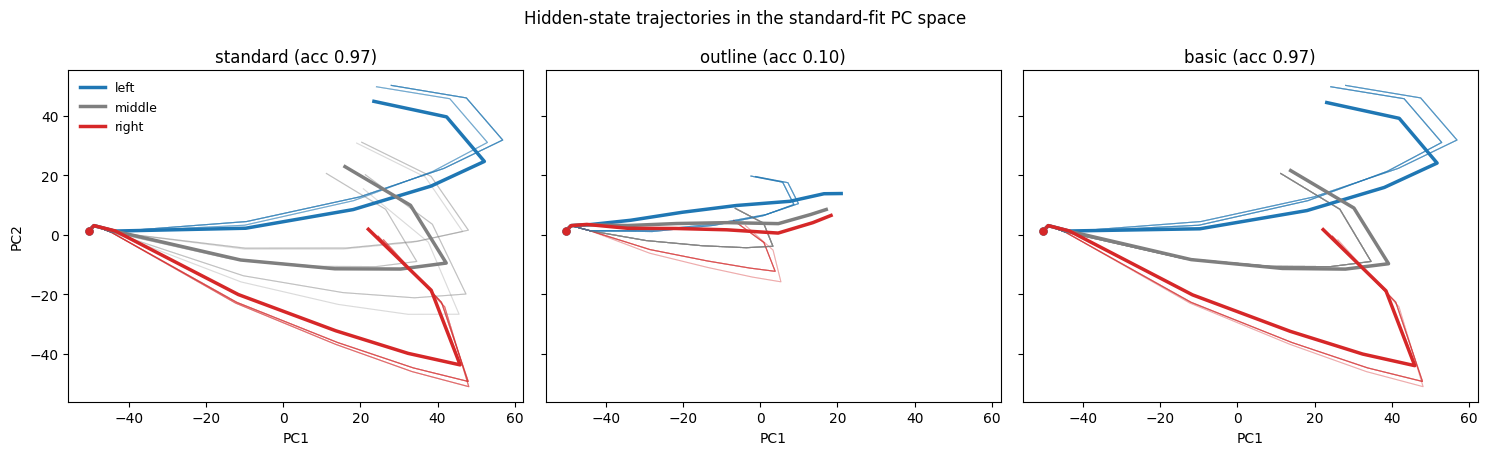

In [2]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 4.6),
                         sharex=True, sharey=True)
for ax, variant in zip(axes, VARIANTS):
    traj = D[f"{variant}_trajectories"]
    labels = D[f"{variant}_labels"]
    mean_traj = D[f"{variant}_mean_trajectories"]
    for t in range(min(50, traj.shape[0])):
        color = DIR_COLORS[int(labels[t])]
        ax.plot(traj[t, :, 0], traj[t, :, 1], color=color, alpha=0.15, lw=0.8)
    for i, cond in enumerate(CONDITIONS):
        ax.plot(mean_traj[i, :, 0], mean_traj[i, :, 1],
                color=DIR_COLORS[int(cond)], lw=2.5, label=DIR_NAMES[int(cond)])
        ax.scatter(mean_traj[i, 0, 0], mean_traj[i, 0, 1],
                   color=DIR_COLORS[int(cond)], s=25, zorder=5)
    ax.set_title(f"{variant} (acc {META['accuracy'][variant]:.2f})")
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Hidden-state trajectories in the standard-fit PC space")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "pca_trajectories.png", dpi=150,
            bbox_inches="tight")

## 2. How much variance do the leading PCs carry?

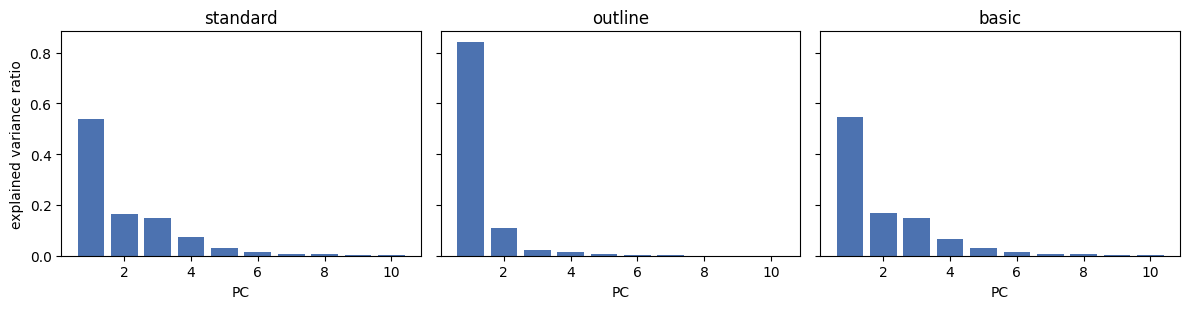

In [3]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4 * len(VARIANTS), 3.2),
                         sharey=True)
for ax, variant in zip(axes, VARIANTS):
    evr = D[f"{variant}_evr"][:10]
    ax.bar(np.arange(1, len(evr) + 1), evr, color="#4c72b0")
    ax.set_title(variant)
    ax.set_xlabel("PC")
axes[0].set_ylabel("explained variance ratio")
fig.tight_layout()

## 3. Time-binned PCA: which units carry the components?

Loadings of the standard variant's top units, per time bin (bins split the 9-step trial into thirds).

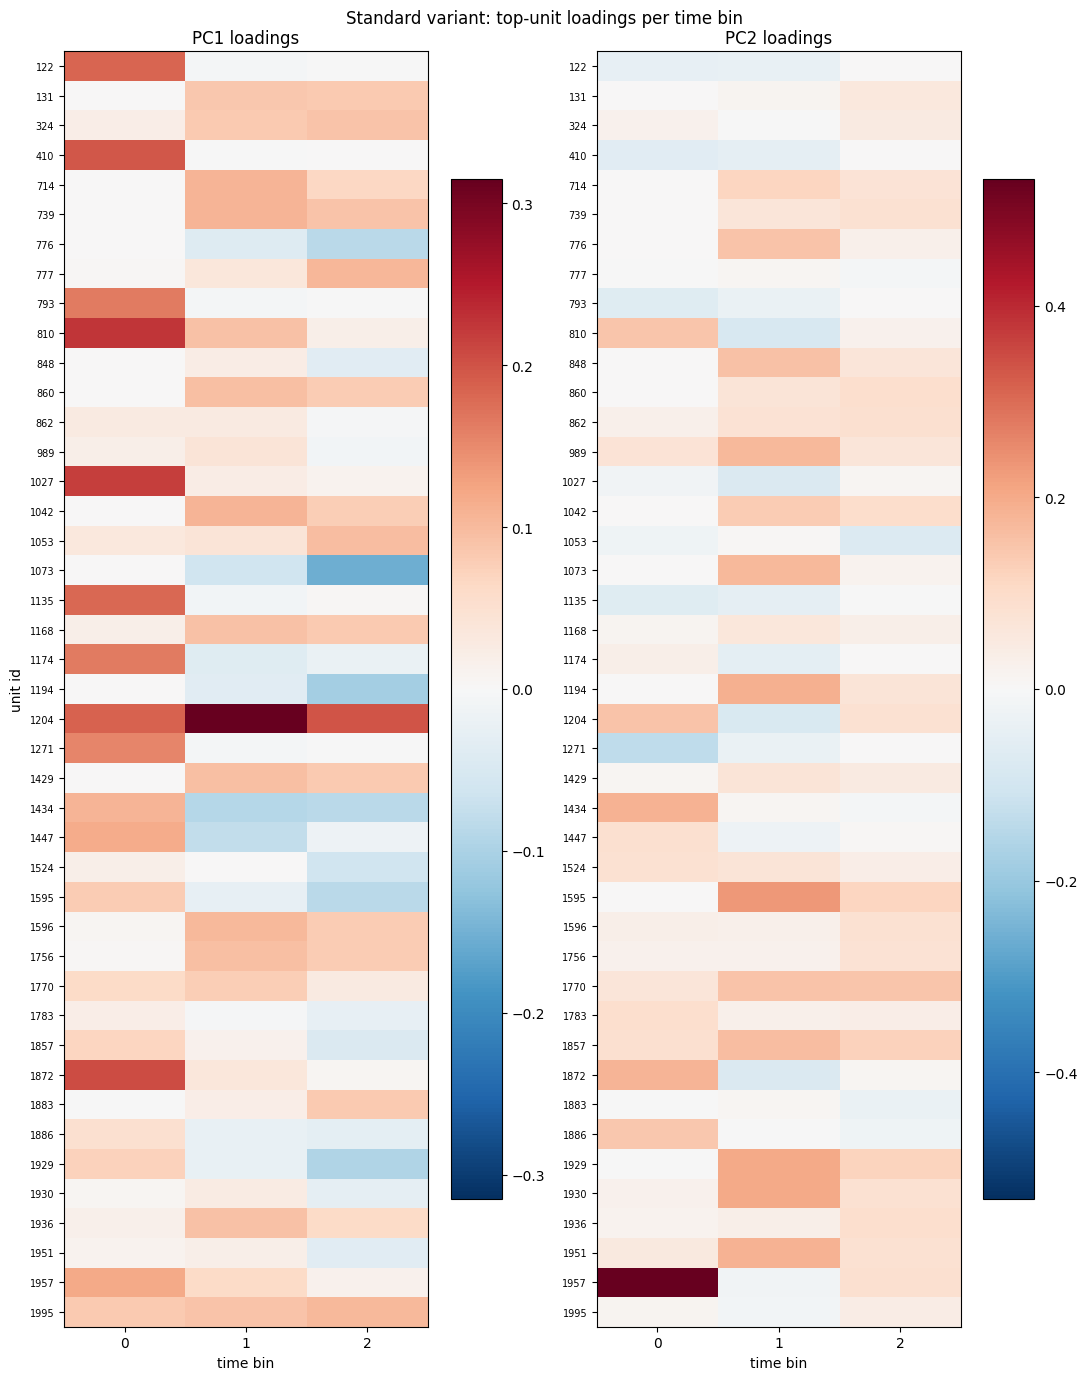

In [4]:
unit_ids = D["standard_unit_ids"]
loadings = D["standard_loadings"]  # (n_bins, 2, N)
n_bins = loadings.shape[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 0.28 * len(unit_ids) + 2))
for pc in range(2):
    mat = loadings[:, pc, :][:, unit_ids]  # (n_bins, M)
    im = axes[pc].imshow(mat.T, aspect="auto", cmap="RdBu_r",
                         vmin=-np.abs(mat).max(), vmax=np.abs(mat).max())
    axes[pc].set_title(f"PC{pc + 1} loadings")
    axes[pc].set_xlabel("time bin")
    axes[pc].set_xticks(range(n_bins))
    axes[pc].set_yticks(range(len(unit_ids)))
    axes[pc].set_yticklabels(unit_ids, fontsize=7)
    fig.colorbar(im, ax=axes[pc], shrink=0.8)
axes[0].set_ylabel("unit id")
fig.suptitle("Standard variant: top-unit loadings per time bin")
fig.tight_layout()

## 4. Top-unit timecourses by condition

Condition means ± s.e.m. for the standard variant's top units, on standard (left column) vs outline (right column) stimuli. Dashed lines: frame1 onset, frame2 onset (first informative frame), decision onset.

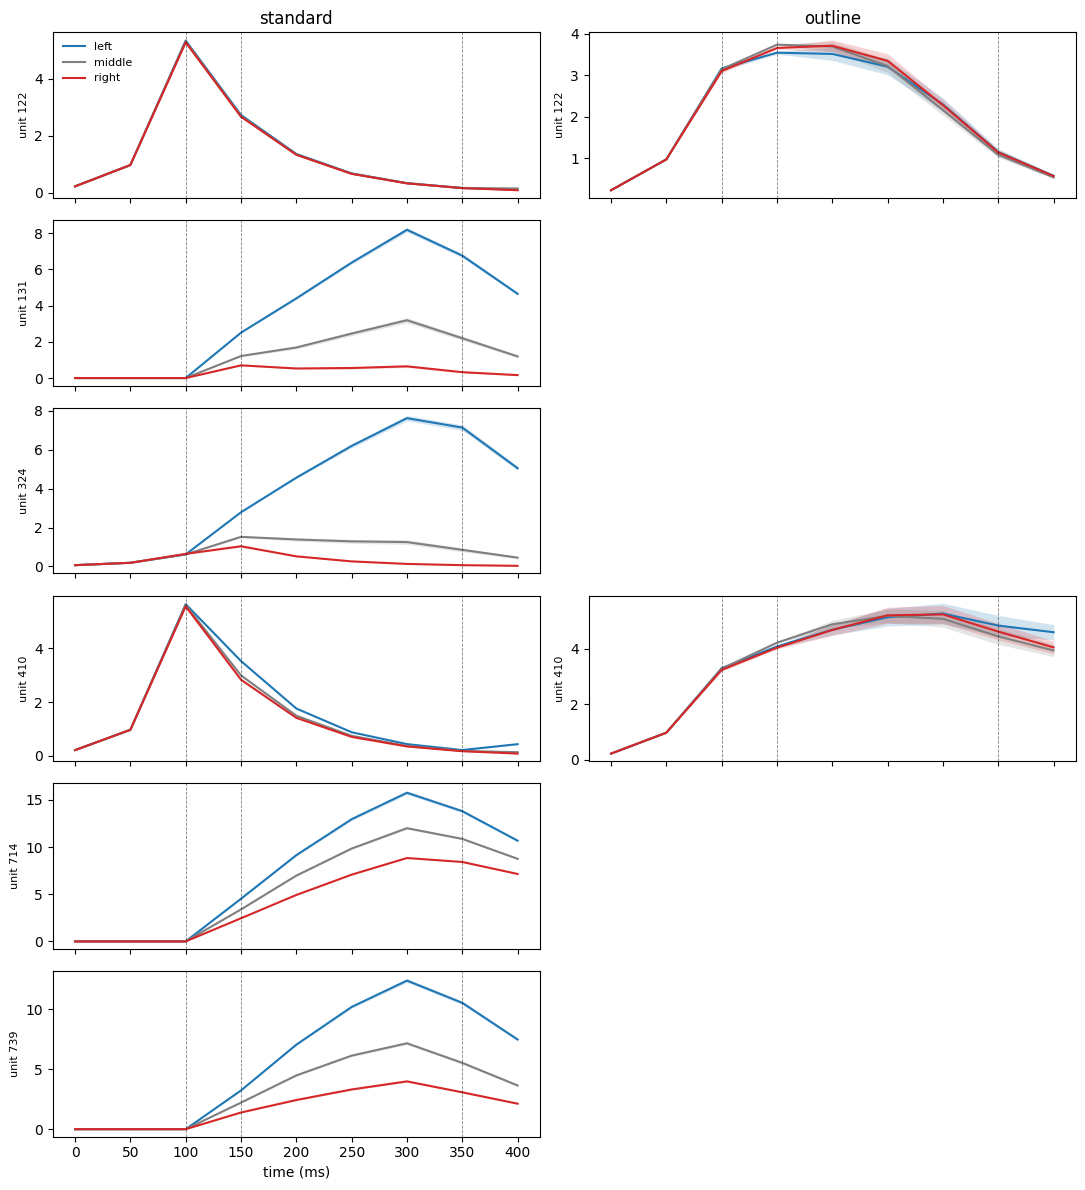

In [5]:
show_variants = [v for v in ("standard", "outline") if v in VARIANTS]
unit_ids = D["standard_unit_ids"]
n_show = min(6, len(unit_ids))
fig, axes = plt.subplots(n_show, len(show_variants),
                         figsize=(5.5 * len(show_variants), 2.0 * n_show),
                         sharex=True, squeeze=False)
for col, variant in enumerate(show_variants):
    ids = D[f"{variant}_unit_ids"]
    mean = D[f"{variant}_unit_mean"]
    sem = D[f"{variant}_unit_sem"]
    for row in range(n_show):
        ax = axes[row][col]
        unit = unit_ids[row]
        where = np.where(ids == unit)[0]
        if len(where) == 0:
            ax.set_visible(False)
            continue
        j = int(where[0])
        for i, cond in enumerate(CONDITIONS):
            color = DIR_COLORS[int(cond)]
            ax.plot(T_MS, mean[i, :, j], color=color,
                    label=DIR_NAMES[int(cond)] if row == 0 else None)
            ax.fill_between(T_MS, mean[i, :, j] - sem[i, :, j],
                            mean[i, :, j] + sem[i, :, j],
                            color=color, alpha=0.2, lw=0)
        for onset in (100, 150, 350):
            ax.axvline(onset, color="k", ls="--", lw=0.6, alpha=0.5)
        ax.set_ylabel(f"unit {unit}", fontsize=8)
        if row == 0:
            ax.set_title(variant)
            if col == 0:
                ax.legend(frameon=False, fontsize=8)
for col in range(len(show_variants)):
    axes[-1][col].set_xlabel("time (ms)")
fig.tight_layout()

## Reading the figures

On the standard and basic variants the condition means separate into direction-specific branches after frame2 (the first informative frame) — the geometry the readout exploits at 0.97 accuracy. Compare the outline panel: if its trajectories fail to branch (or branch into a different geometry), the behavioral collapse to ~0.10 has a representational counterpart. Notebook 04 quantifies exactly that with RSA.